# 第二十六章：CLIP — PyTorch 實作

本 notebook 實作 CLIP 模型的核心概念，展示對比學習和零樣本分類。

**論文**: Learning Transferable Visual Models From Natural Language Supervision  
**作者**: Alec Radford, Jong Wook Kim et al.  
**機構**: OpenAI  
**發表**: arXiv:2103.00020, February 2021 (ICML 2021)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import math

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 檢查 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

使用裝置: cuda


## 26.1 CLIP 架構概覽

CLIP 由兩個編碼器組成：
1. **圖像編碼器**：將圖像映射到嵌入空間
2. **文字編碼器**：將文字映射到相同的嵌入空間

訓練目標是讓配對的圖文嵌入相近，不配對的嵌入遠離。

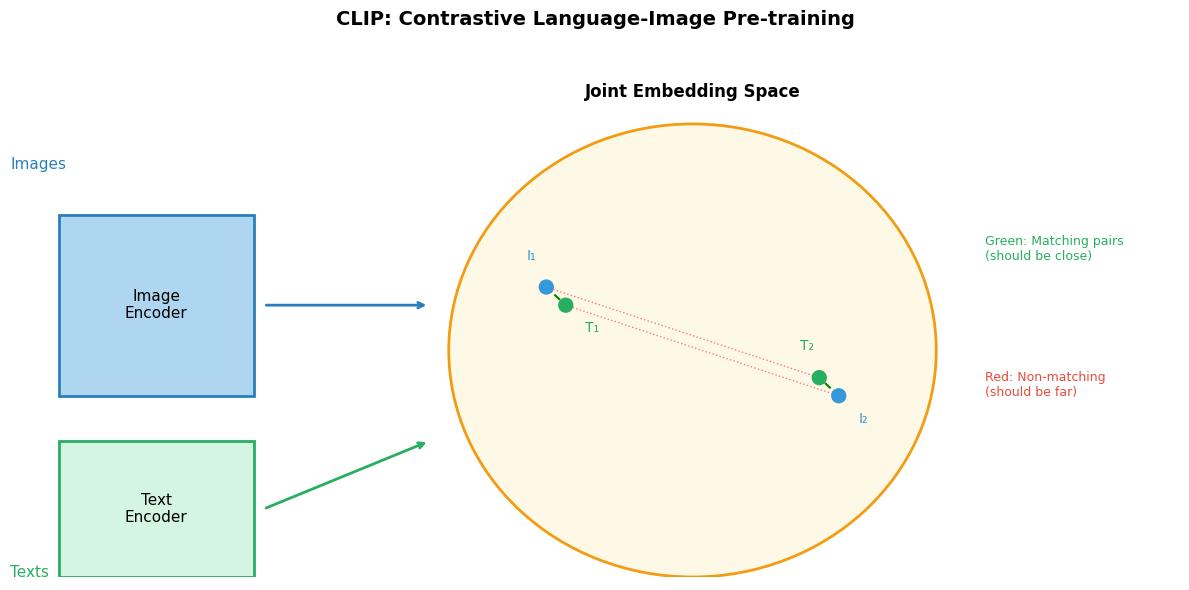

In [2]:
# 視覺化 CLIP 概念
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

# 圖像編碼器
rect1 = plt.Rectangle((0.5, 2), 2, 2, facecolor='#aed6f1', edgecolor='#2980b9', linewidth=2)
ax.add_patch(rect1)
ax.text(1.5, 3, 'Image\nEncoder', ha='center', va='center', fontsize=11)

# 文字編碼器
rect2 = plt.Rectangle((0.5, 0), 2, 1.5, facecolor='#d5f5e3', edgecolor='#27ae60', linewidth=2)
ax.add_patch(rect2)
ax.text(1.5, 0.75, 'Text\nEncoder', ha='center', va='center', fontsize=11)

# 嵌入空間
circle = plt.Circle((7, 2.5), 2.5, facecolor='#fef9e7', edgecolor='#f39c12', linewidth=2)
ax.add_patch(circle)
ax.text(7, 5.3, 'Joint Embedding Space', ha='center', fontsize=12, fontweight='bold')

# 嵌入點
# 配對的圖文
ax.scatter([5.5, 5.7], [3.2, 3.0], c=['#3498db', '#27ae60'], s=100, zorder=5)
ax.plot([5.5, 5.7], [3.2, 3.0], 'g--', linewidth=1.5)
ax.text(5.3, 3.5, 'I₁', fontsize=10, color='#3498db')
ax.text(5.9, 2.7, 'T₁', fontsize=10, color='#27ae60')

# 另一組配對
ax.scatter([8.5, 8.3], [2.0, 2.2], c=['#3498db', '#27ae60'], s=100, zorder=5)
ax.plot([8.5, 8.3], [2.0, 2.2], 'g--', linewidth=1.5)
ax.text(8.7, 1.7, 'I₂', fontsize=10, color='#3498db')
ax.text(8.1, 2.5, 'T₂', fontsize=10, color='#27ae60')

# 不配對的連線（紅色虛線）
ax.plot([5.5, 8.3], [3.2, 2.2], 'r:', linewidth=1, alpha=0.5)
ax.plot([5.7, 8.5], [3.0, 2.0], 'r:', linewidth=1, alpha=0.5)

# 箭頭
ax.annotate('', xy=(4.3, 3), xytext=(2.6, 3),
            arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2))
ax.annotate('', xy=(4.3, 1.5), xytext=(2.6, 0.75),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))

# 輸入
ax.text(0, 4.5, 'Images', fontsize=11, color='#2980b9')
ax.text(0, 0, 'Texts', fontsize=11, color='#27ae60')

# 說明
ax.text(10, 3.5, 'Green: Matching pairs\n(should be close)', fontsize=9, color='#27ae60')
ax.text(10, 2, 'Red: Non-matching\n(should be far)', fontsize=9, color='#e74c3c')

plt.title('CLIP: Contrastive Language-Image Pre-training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clip_concept.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 26.2 簡化版圖像編碼器

In [3]:
class SimpleImageEncoder(nn.Module):
    """
    簡化版圖像編碼器（基於 ResNet）
    實際 CLIP 使用 ViT 或修改過的 ResNet
    """
    def __init__(self, embed_dim=512):
        super().__init__()
        # 使用預訓練的 ResNet18 作為骨幹
        resnet = models.resnet18(pretrained=False)
        # 移除最後的全連接層
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.projection = nn.Linear(512, embed_dim)
    
    def forward(self, x):
        # x: (B, 3, H, W)
        features = self.backbone(x)  # (B, 512, 1, 1)
        features = features.flatten(1)  # (B, 512)
        embeddings = self.projection(features)  # (B, embed_dim)
        return F.normalize(embeddings, dim=-1)

# 測試
image_encoder = SimpleImageEncoder(embed_dim=256)
test_images = torch.randn(4, 3, 224, 224)
image_embeddings = image_encoder(test_images)
print(f"圖像輸入形狀: {test_images.shape}")
print(f"圖像嵌入形狀: {image_embeddings.shape}")
print(f"嵌入向量範數: {image_embeddings.norm(dim=-1)}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


圖像輸入形狀: torch.Size([4, 3, 224, 224])
圖像嵌入形狀: torch.Size([4, 256])
嵌入向量範數: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)


## 26.3 簡化版文字編碼器

In [4]:
class SimpleTextEncoder(nn.Module):
    """
    簡化版文字編碼器（基於 Transformer）
    """
    def __init__(self, vocab_size=10000, max_len=77, embed_dim=512, 
                 num_layers=6, num_heads=8, hidden_dim=2048):
        super().__init__()
        self.max_len = max_len
        self.embed_dim = embed_dim
        
        # Token embedding
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        # Positional embedding
        self.positional_embedding = nn.Parameter(torch.randn(max_len, embed_dim) * 0.01)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=hidden_dim, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # LayerNorm
        self.ln_final = nn.LayerNorm(embed_dim)
        
        # Projection
        self.projection = nn.Linear(embed_dim, embed_dim)
    
    def forward(self, text, attention_mask=None):
        """
        Args:
            text: (B, L) token ids
            attention_mask: (B, L) mask for padding
        Returns:
            (B, embed_dim) text embeddings
        """
        B, L = text.shape
        
        # Embedding
        x = self.token_embedding(text)  # (B, L, D)
        x = x + self.positional_embedding[:L]  # Add positional embedding
        
        # Create causal mask (not used in CLIP, but for completeness)
        # Transformer
        x = self.transformer(x)
        
        # Take the [EOS] token representation (last token before padding)
        # 簡化：取最後一個非 padding token
        x = self.ln_final(x)
        
        if attention_mask is not None:
            # 找到每個序列的最後一個有效 token
            seq_lengths = attention_mask.sum(dim=1) - 1
            x = x[torch.arange(B), seq_lengths.long()]
        else:
            x = x[:, -1]  # 取最後一個 token
        
        x = self.projection(x)
        return F.normalize(x, dim=-1)

# 測試
text_encoder = SimpleTextEncoder(vocab_size=1000, embed_dim=256, num_layers=4)
test_tokens = torch.randint(0, 1000, (4, 20))  # 4 個序列，每個長度 20
text_embeddings = text_encoder(test_tokens)
print(f"文字輸入形狀: {test_tokens.shape}")
print(f"文字嵌入形狀: {text_embeddings.shape}")
print(f"嵌入向量範數: {text_embeddings.norm(dim=-1)}")

文字輸入形狀: torch.Size([4, 20])
文字嵌入形狀: torch.Size([4, 256])
嵌入向量範數: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)


## 26.4 完整 CLIP 模型

In [5]:
class SimpleCLIP(nn.Module):
    """
    簡化版 CLIP 模型
    """
    def __init__(self, embed_dim=256, vocab_size=1000):
        super().__init__()
        self.image_encoder = SimpleImageEncoder(embed_dim=embed_dim)
        self.text_encoder = SimpleTextEncoder(vocab_size=vocab_size, embed_dim=embed_dim, num_layers=4)
        
        # 可學習的溫度參數
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
    
    def encode_image(self, image):
        return self.image_encoder(image)
    
    def encode_text(self, text):
        return self.text_encoder(text)
    
    def forward(self, image, text):
        image_features = self.encode_image(image)
        text_features = self.encode_text(text)
        
        # 計算相似度
        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()
        
        return logits_per_image, logits_per_text

# 創建模型
clip_model = SimpleCLIP(embed_dim=256, vocab_size=1000).to(device)
print(f"模型參數量: {sum(p.numel() for p in clip_model.parameters()):,}")

模型參數量: 16,910,145


## 26.5 對比學習損失函數

相似度矩陣形狀: torch.Size([8, 8])
對比損失: 2.2756


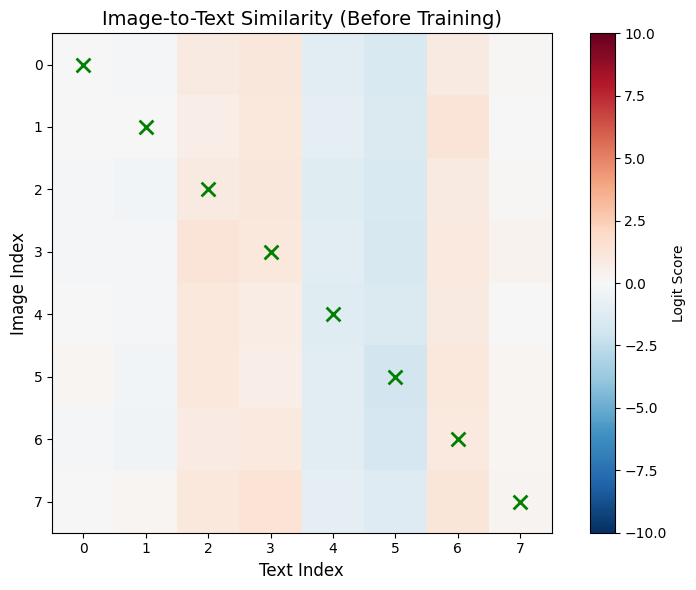

In [6]:
def clip_loss(logits_per_image, logits_per_text):
    """
    CLIP 的對稱對比損失
    
    對角線元素是正確的圖文配對，應該最大化
    非對角線元素是錯誤的配對，應該最小化
    """
    batch_size = logits_per_image.shape[0]
    # 標籤就是對角線索引
    labels = torch.arange(batch_size, device=logits_per_image.device)
    
    # 圖像到文字的損失
    loss_i2t = F.cross_entropy(logits_per_image, labels)
    # 文字到圖像的損失
    loss_t2i = F.cross_entropy(logits_per_text, labels)
    
    return (loss_i2t + loss_t2i) / 2

# 視覺化相似度矩陣
def visualize_similarity_matrix(logits, title="Similarity Matrix"):
    plt.figure(figsize=(8, 6))
    plt.imshow(logits.detach().cpu().numpy(), cmap='RdBu_r', vmin=-10, vmax=10)
    plt.colorbar(label='Logit Score')
    plt.xlabel('Text Index', fontsize=12)
    plt.ylabel('Image Index', fontsize=12)
    plt.title(title, fontsize=14)
    
    # 標記對角線
    n = logits.shape[0]
    for i in range(n):
        plt.scatter(i, i, c='green', s=100, marker='x', linewidths=2)
    
    plt.tight_layout()
    plt.savefig('similarity_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

# 測試
test_images = torch.randn(8, 3, 224, 224).to(device)
test_texts = torch.randint(0, 1000, (8, 20)).to(device)

logits_i2t, logits_t2i = clip_model(test_images, test_texts)
loss = clip_loss(logits_i2t, logits_t2i)

print(f"相似度矩陣形狀: {logits_i2t.shape}")
print(f"對比損失: {loss.item():.4f}")

visualize_similarity_matrix(logits_i2t, "Image-to-Text Similarity (Before Training)")

## 26.6 模擬訓練過程

In [7]:
# 創建一個簡單的圖文配對資料集
class SimpleImageTextDataset(Dataset):
    """
    模擬的圖文配對資料集
    實際上只是隨機資料，用於演示訓練流程
    """
    def __init__(self, size=1000, vocab_size=1000, text_len=20):
        self.size = size
        self.vocab_size = vocab_size
        self.text_len = text_len
        
        # 生成隨機圖像
        self.images = torch.randn(size, 3, 224, 224)
        # 生成隨機文字 token
        self.texts = torch.randint(0, vocab_size, (size, text_len))
    
    def __len__(self):
        return self.size
    
    def __getitem__(self, idx):
        return self.images[idx], self.texts[idx]

# 訓練函數
def train_clip(model, dataloader, epochs=5, lr=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    losses = []
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, (images, texts) in enumerate(dataloader):
            images = images.to(device)
            texts = texts.to(device)
            
            # 前向傳播
            logits_i2t, logits_t2i = model(images, texts)
            loss = clip_loss(logits_i2t, logits_t2i)
            
            # 反向傳播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}: 平均損失 = {avg_loss:.4f}')
    
    return losses

# 創建資料集和 dataloader
dataset = SimpleImageTextDataset(size=500, vocab_size=1000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 訓練
print("開始訓練 CLIP...")
losses = train_clip(clip_model, dataloader, epochs=10, lr=1e-4)

開始訓練 CLIP...
Epoch 1: 平均損失 = 3.5043
Epoch 2: 平均損失 = 2.5992
Epoch 3: 平均損失 = 0.2721
Epoch 4: 平均損失 = 0.0306
Epoch 5: 平均損失 = 0.0158
Epoch 6: 平均損失 = 0.0087
Epoch 7: 平均損失 = 0.0080
Epoch 8: 平均損失 = 0.0091
Epoch 9: 平均損失 = 0.0051
Epoch 10: 平均損失 = 0.0097


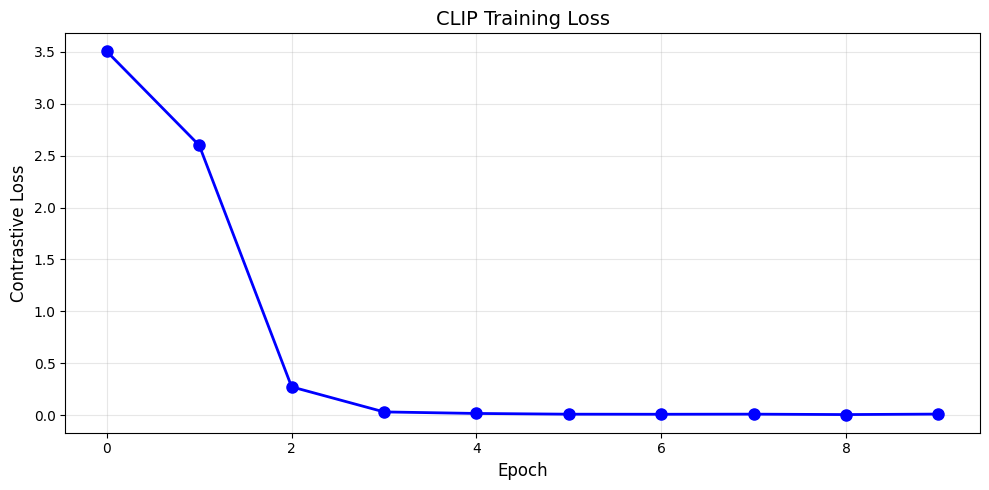

In [8]:
# 視覺化訓練損失
plt.figure(figsize=(10, 5))
plt.plot(losses, 'b-', linewidth=2, marker='o', markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Contrastive Loss', fontsize=12)
plt.title('CLIP Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clip_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 26.7 零樣本分類演示

In [9]:
def zero_shot_classification(model, images, class_embeddings):
    """
    零樣本分類
    
    Args:
        model: CLIP 模型
        images: 輸入圖像 (B, 3, H, W)
        class_embeddings: 類別文字嵌入 (num_classes, embed_dim)
    Returns:
        predictions: 預測類別索引
        probabilities: 各類別機率
    """
    model.eval()
    with torch.no_grad():
        image_embeddings = model.encode_image(images)
        
        # 計算相似度
        logit_scale = model.logit_scale.exp()
        logits = logit_scale * image_embeddings @ class_embeddings.t()
        
        # 轉換為機率
        probabilities = F.softmax(logits, dim=-1)
        predictions = logits.argmax(dim=-1)
    
    return predictions, probabilities

# 模擬零樣本分類
print("\n=== 零樣本分類演示 ===")

# 假設有 5 個類別
class_names = ['cat', 'dog', 'car', 'tree', 'house']
num_classes = len(class_names)

# 生成隨機的類別嵌入（實際應該用文字編碼器編碼類別名稱）
class_embeddings = torch.randn(num_classes, 256).to(device)
class_embeddings = F.normalize(class_embeddings, dim=-1)

# 測試圖像
test_images = torch.randn(4, 3, 224, 224).to(device)

# 零樣本分類
predictions, probabilities = zero_shot_classification(clip_model, test_images, class_embeddings)

print(f"\n預測結果：")
for i, (pred, probs) in enumerate(zip(predictions, probabilities)):
    print(f"\n圖像 {i+1}:")
    print(f"  預測類別: {class_names[pred]}")
    print(f"  各類機率: {dict(zip(class_names, probs.cpu().numpy().round(3)))}")


=== 零樣本分類演示 ===

預測結果：

圖像 1:
  預測類別: house
  各類機率: {'cat': np.float32(0.222), 'dog': np.float32(0.227), 'car': np.float32(0.108), 'tree': np.float32(0.213), 'house': np.float32(0.231)}

圖像 2:
  預測類別: cat
  各類機率: {'cat': np.float32(0.719), 'dog': np.float32(0.112), 'car': np.float32(0.039), 'tree': np.float32(0.047), 'house': np.float32(0.082)}

圖像 3:
  預測類別: tree
  各類機率: {'cat': np.float32(0.234), 'dog': np.float32(0.12), 'car': np.float32(0.061), 'tree': np.float32(0.402), 'house': np.float32(0.183)}

圖像 4:
  預測類別: cat
  各類機率: {'cat': np.float32(0.566), 'dog': np.float32(0.13), 'car': np.float32(0.12), 'tree': np.float32(0.054), 'house': np.float32(0.131)}


## 26.8 嵌入空間視覺化

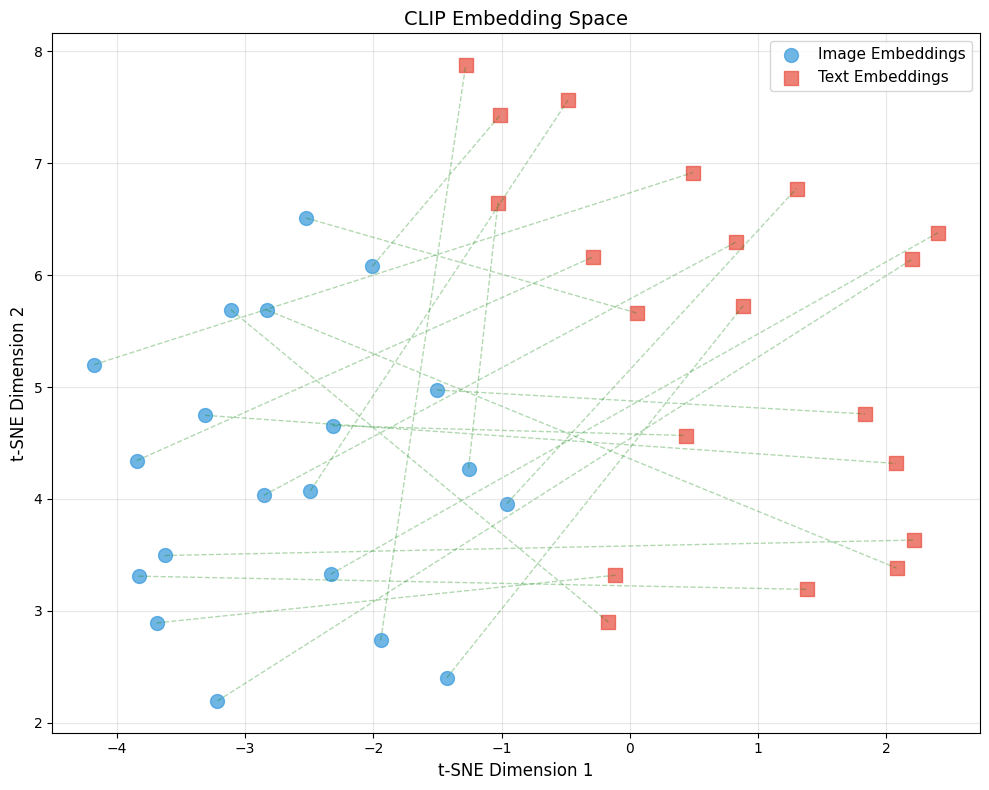

In [10]:
from sklearn.manifold import TSNE

def visualize_embedding_space(image_embeddings, text_embeddings, title="CLIP Embedding Space"):
    """
    使用 t-SNE 視覺化嵌入空間
    """
    # 合併嵌入
    all_embeddings = torch.cat([image_embeddings, text_embeddings], dim=0)
    all_embeddings = all_embeddings.cpu().numpy()
    
    # t-SNE 降維
    tsne = TSNE(n_components=2, perplexity=min(30, len(all_embeddings)//2), random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings)
    
    n_images = len(image_embeddings)
    
    # 繪圖
    plt.figure(figsize=(10, 8))
    
    # 圖像嵌入
    plt.scatter(embeddings_2d[:n_images, 0], embeddings_2d[:n_images, 1], 
                c='#3498db', marker='o', s=100, label='Image Embeddings', alpha=0.7)
    
    # 文字嵌入
    plt.scatter(embeddings_2d[n_images:, 0], embeddings_2d[n_images:, 1], 
                c='#e74c3c', marker='s', s=100, label='Text Embeddings', alpha=0.7)
    
    # 連接配對
    for i in range(n_images):
        plt.plot([embeddings_2d[i, 0], embeddings_2d[n_images + i, 0]],
                [embeddings_2d[i, 1], embeddings_2d[n_images + i, 1]],
                'g--', alpha=0.3, linewidth=1)
    
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('embedding_space.png', dpi=150, bbox_inches='tight')
    plt.show()

# 生成嵌入
clip_model.eval()
with torch.no_grad():
    test_images = torch.randn(20, 3, 224, 224).to(device)
    test_texts = torch.randint(0, 1000, (20, 20)).to(device)
    
    image_embeddings = clip_model.encode_image(test_images)
    text_embeddings = clip_model.encode_text(test_texts)

visualize_embedding_space(image_embeddings, text_embeddings)

## 26.9 溫度參數的影響

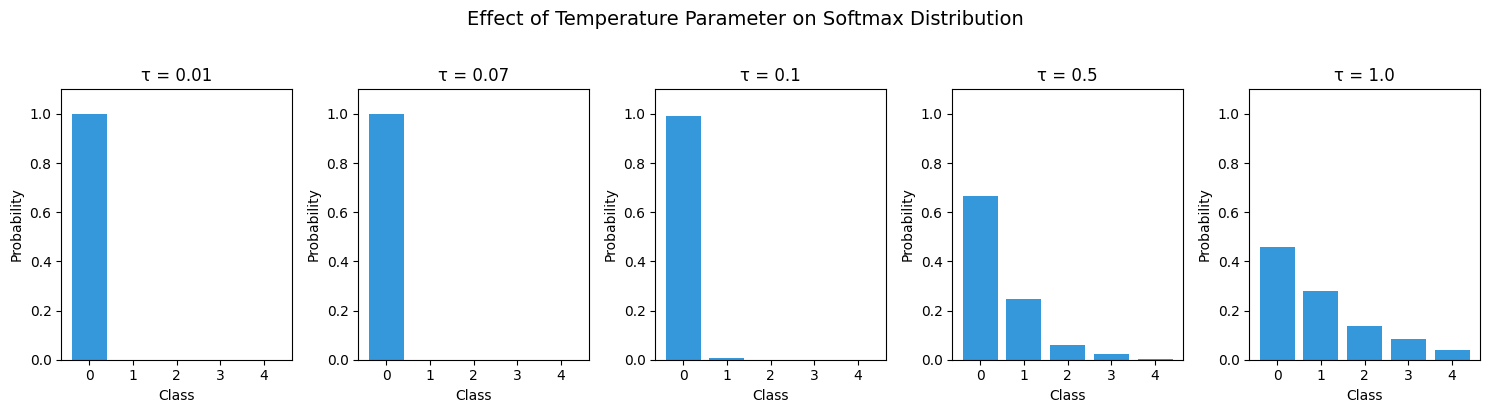

In [11]:
def visualize_temperature_effect():
    """
    視覺化溫度參數對 softmax 分布的影響
    """
    # 模擬相似度分數
    logits = torch.tensor([2.0, 1.5, 0.8, 0.3, -0.5])
    
    temperatures = [0.01, 0.07, 0.1, 0.5, 1.0]
    
    fig, axes = plt.subplots(1, len(temperatures), figsize=(15, 4))
    
    for ax, temp in zip(axes, temperatures):
        probs = F.softmax(logits / temp, dim=-1).numpy()
        ax.bar(range(5), probs, color='#3498db')
        ax.set_xlabel('Class', fontsize=10)
        ax.set_ylabel('Probability', fontsize=10)
        ax.set_title(f'τ = {temp}', fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.set_xticks(range(5))
    
    plt.suptitle('Effect of Temperature Parameter on Softmax Distribution', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('temperature_effect.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_temperature_effect()

## 26.10 本章總結

### 主要實作內容

1. **圖像編碼器**: 基於 ResNet 的簡化版本
2. **文字編碼器**: 基於 Transformer 的編碼器
3. **對比學習損失**: InfoNCE 風格的對稱損失
4. **零樣本分類**: 使用文字嵌入作為分類器
5. **嵌入空間視覺化**: t-SNE 降維分析

### CLIP 的核心公式

1. **相似度計算**: $S_{ij} = \tau \cdot \mathbf{z}_I^i \cdot (\mathbf{z}_T^j)^\top$
2. **損失函數**: $L = \frac{1}{2}(L_{I \rightarrow T} + L_{T \rightarrow I})$
3. **零樣本分類**: $\hat{y} = \arg\max_c \cos(f_I(x), f_T(c))$

### 實際應用

- 圖像分類（無需訓練資料）
- 圖像檢索
- 內容審核
- 引導圖像生成

In [12]:
print("第二十六章 CLIP 實作完成！")
print("\n生成的圖片：")
print("- clip_concept.png: CLIP 概念示意圖")
print("- similarity_matrix.png: 相似度矩陣")
print("- clip_training_loss.png: 訓練損失曲線")
print("- embedding_space.png: 嵌入空間視覺化")
print("- temperature_effect.png: 溫度參數影響")

第二十六章 CLIP 實作完成！

生成的圖片：
- clip_concept.png: CLIP 概念示意圖
- similarity_matrix.png: 相似度矩陣
- clip_training_loss.png: 訓練損失曲線
- embedding_space.png: 嵌入空間視覺化
- temperature_effect.png: 溫度參數影響
